## B. Geometric Brownian Motion 

Student number: u2012113


The stochastic differential equation

$$
\dot S(t) = \mu S(t) + \sigma S(t) \xi(t)
$$

plays a central role in mathematical finance. This equation describes what is known as [Geometric Brownian Motion](https://en.wikipedia.org/wiki/Geometric_Brownian_motion).  $S(t)$ is taken to be positive and represents the value of a stock at time $t$. The deterministic ODE $\dot S(t) = \mu S(t)$, describes exponential growth in the value of a stock. We consider $\mu > 0$ and refer to $\mu$ as the growth rate. The term $\sigma S(t) \xi(t)$ describes fluctuations in the value of a stock. $\xi(t)$ is a Gaussian random variable. The parameter $\sigma > 0$ is known as the volatility. Notice that the fluctuating term contains $S(t)$ itself. This models the fact that fluctuations in a stock price are proportional to the price. 

Time $t$ is measured in years. Typical values for $\mu$ are between $0.01$ and $0.10$, corresponding to 1% and 10% annual growth (non-compounded). We assume values for $\sigma$ are between $0.1$ and $0.4$. 

The aim of this model is to predict how stock prices will change. The code below computes and plots the solution to the stochastic differential equation with parameters of $\mu=0.1$ and $\sigma=0.25$, $tf=5years$ and initial value of stock price $S0=100$. The first figure plots 10 sample paths with the parameters chosen. As we can see in the plot, most of the values of the stocks increase through time but very few of them increase considerably. 

The next figures call the function for the same parameters but with 2000 sample paths. The first shows mean of the stock prices through time and the standard deviation. The mean is strictly increasing, however after 5 years is not much greater than the initial value. The last figures plots three histograms of the value of stock prices for three chosen times 1year, 2years, and 5 year. The data of stock prices follow a lognormal distribution.

[This](https://www.investopedia.com/articles/07/montecarlo.asp) and [this](https://www.investopedia.com/ask/answers/021015/how-can-you-calculate-volatility-excel.asp) are simple articles on [investopedia.com](https://www.investopedia.com) that might be of interest.



In [1]:
# Import libraries 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.integrate import odeint

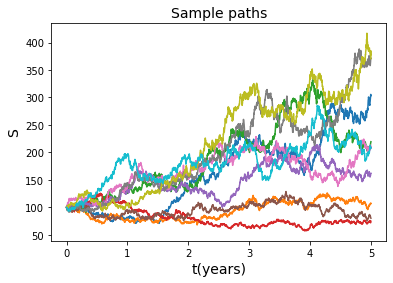

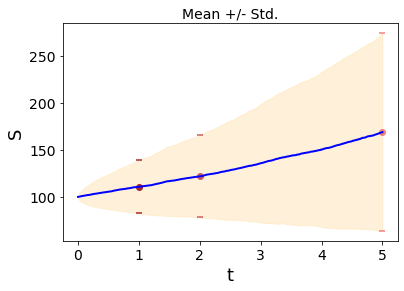

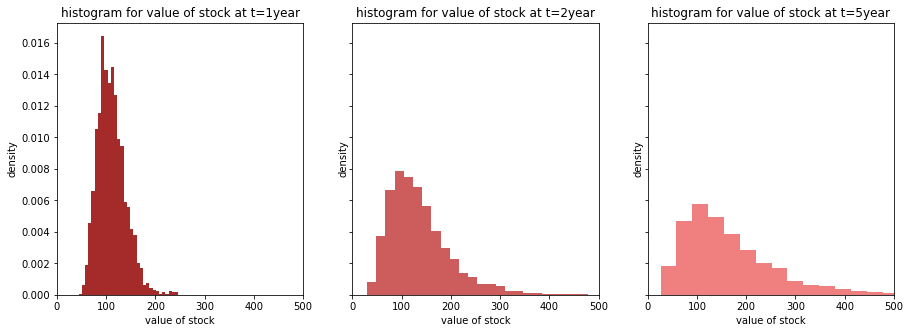

The mean of S at t=1 (1year) is 110.63910260520898
The standard deviation of S at t=1 (1year) is 28.20889413439616

The mean of S at t=2 (2year) is 135.73403473576485
The standard deviation of S at t=2 (2years) is 62.6458354191725

The mean of S at t=5 (5year) is 168.69266372332157
The standard deviation of S at t=5 (5years) is 104.70589775671898


In [3]:
# --- First define the function  --- #

def SDE_GBM(S0,tf,mu,sigma,Npaths):
  
    # Generate the time grid and solution array
    Nsteps = tf*365
    t, dt = np.linspace(0,tf,Nsteps+1,retstep=True)
    S = np.zeros((Nsteps+1,Npaths))
    root_dt = np.sqrt(dt)

    # Time step starting from initial condition
    S[0,:] = S0;
    for n in range(Nsteps):
        F_of_S = mu * S[n,:]
        S[n+1,:] =  S[n,:] + dt * F_of_S + S[n,:]*sigma * root_dt * np.random.randn(Npaths)
        
    return t,S


# --- Call function with 10 paths  --- #

t,S = SDE_GBM(S0=100, tf = 5, mu=0.1, sigma = 0.25, Npaths=10)


# --- Plots --- #

# plot sample paths
plt.plot(t,S)

# labels 
plt.xlabel("t(years)", fontsize=14)
plt.ylabel("S", fontsize=14)
plt.title("Sample paths", fontsize=14)
plt.show()


# --- Call function with 2000 paths --- #

t,S = SDE_GBM(S0=100, tf = 5, mu=0.1, sigma = 0.25, Npaths=2000)


# ---Plot to show mean +/- standard deviation as function of time. --- #

# Compute the mean and standard deviation as function of time
S_mean = np.mean(S,1)
S_std = np.std(S,1)

# Plot shaded region between S_mean - S_std and S_mean + S_std 
plt.fill_between(t, 
                 S_mean - S_std, 
                 S_mean + S_std, 
                 alpha=0.5, color="moccasin")

# Plot the mean itself
plt.plot(t,S_mean, linewidth=2,color = 'blue')

# Compute mean and standard deviation at 3 specific times (1year,2years,5years)
mean_1 = S_mean[364]
std_1 = S_std[364]

mean_2 = S_mean[729]
std_2 = S_std[729]

mean_3 = S_mean[-1]
std_3 = S_std[-1]

# Mark the points S_mean, S_mean - S_std and S_mean + S_std for those 3 specific values of t (1year,3years,5years)
plt.scatter(1,mean_1,c = 'brown')
plt.scatter(1,mean_1-std_1, marker = '_', c= 'brown')
plt.scatter(1,mean_1+std_1, marker = '_',c= 'brown')

plt.scatter(2,mean_2,c = 'indianred')
plt.scatter(2,mean_2-std_2, marker = '_', c= 'indianred')
plt.scatter(2,mean_2+std_2, marker = '_',c= 'indianred')

plt.scatter(5,mean_3,c = 'lightcoral')
plt.scatter(5,mean_3-std_3, marker = '_', c= 'lightcoral')
plt.scatter(5,mean_3+std_3, marker = '_',c= 'lightcoral')

# labels
plt.xlabel("t", fontsize=18)
plt.ylabel("S", fontsize=18)

plt.title("Mean +/- Std.", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# --- Plot histograms at three times (1year,2years,5years) with same limits --- #

# histograms 
fig,axs=plt.subplots(1,3, sharex=True, sharey=True, figsize=(15,5))
axs[0].hist(S[364,:], bins = 31, density=True, color = 'brown' )
axs[1].hist(S[1094,:],bins = 31, density=True, color = 'indianred' )
axs[2].hist(S[-1,:],bins = 31, density=True, color= 'lightcoral')

# adds titles to histograms

axs[0].title.set_text('histogram for value of stock at t=1year')
axs[1].title.set_text('histogram for value of stock at t=2year')
axs[2].title.set_text('histogram for value of stock at t=5year')

# adds labels to subplot axis
axs[0].set_xlabel('value of stock')
axs[1].set_xlabel('value of stock')
axs[2].set_xlabel('value of stock')
axs[0].set_ylabel('density')
axs[1].set_ylabel('density')
axs[2].set_ylabel('density')
plt.xlim(0,500)
plt.show()


# --- Report means and standard deviations --- #

print("The mean of S at t=1 (1year) is", np.mean(S[364,:]))
print("The standard deviation of S at t=1 (1year) is", np.std(S[364,:]))
print()
print("The mean of S at t=2 (2year) is", np.mean(S[1094,:]))
print("The standard deviation of S at t=2 (2years) is", np.std(S[1094,:]))
print()
print("The mean of S at t=5 (5year) is", np.mean(S[-1,:]))
print("The standard deviation of S at t=5 (5years) is", np.std(S[-1,:]))